THERMA-SENSE: IOT MICROCLIMATE INTELLIGENCE & HEAT STRESS ANALYTICS

In [1]:
import os
import io
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import classification_report, confusion_matrix, r2_score, mean_squared_error, mean_absolute_error

warnings.filterwarnings('ignore')

1. DATA INGESTION & SYNTHETIC AUGMENTATION

In [8]:
if os.path.exists('data.csv'):
    try:
        df_raw = pd.read_csv('data.csv')
        df_raw.columns = df_raw.columns.str.strip().str.lower()
        if not {'indoor_temp', 'indoor_humidity'}.issubset(df_raw.columns):
            df_raw = None
    except Exception:
        df_raw = None
else:
    df_raw = None

Augment random telemetry rows based on Dhaka microclimate dynamics

In [9]:
np.random.seed(42)
AUGMENT_ROWS = 1500

in_temp = np.random.normal(27.0, 3.8, AUGMENT_ROWS)
in_hum = np.random.normal(62.0, 12.5, AUGMENT_ROWS)
out_temp = in_temp + np.random.normal(4.2, 2.3, AUGMENT_ROWS)
out_hum = in_hum + np.random.normal(8.5, 7.5, AUGMENT_ROWS)

df_synth = pd.DataFrame({
    'indoor_temp': np.clip(in_temp, 16.0, 42.0).round(2),
    'indoor_humidity': np.clip(in_hum, 20.0, 98.0).round(2),
    'outdoor_temp': np.clip(out_temp, 18.0, 48.0).round(2),
    'outdoor_humidity': np.clip(out_hum, 25.0, 99.0).round(2)
})

if df_raw is not None:
    # Retain existing columns and append augmented samples
    common_cols = [c for c in ['indoor_temp', 'indoor_humidity', 'outdoor_temp', 'outdoor_humidity'] if c in df_raw.columns]
    df = pd.concat([df_raw[common_cols], df_synth], ignore_index=True)
    if 'outdoor_temp' not in df.columns:
        df['outdoor_temp'] = (df['indoor_temp'] + 4.0).round(2)
    if 'outdoor_humidity' not in df.columns:
        df['outdoor_humidity'] = (df['indoor_humidity'] + 10.0).round(2)
else:
    df = df_synth.copy()

2. FEATURE ENGINEERING & CLINICAL THRESHOLDING

In [10]:
def calculate_noaa_heat_index(temp_c, rh):
    """Calculates Steadman/Rothfusz Heat Index in Celsius."""
    tf = temp_c * 9.0 / 5.0 + 32.0
    hi = 0.5 * (tf + 61.0 + ((tf - 68.0) * 1.2) + (rh * 0.094))
    if hi >= 80.0:
        hi = (-42.379 + 2.04901523 * tf + 10.14333127 * rh
              - 0.22475541 * tf * rh - 0.00683783 * (tf**2)
              - 0.05481717 * (rh**2) + 0.00122874 * (tf**2) * rh
              + 0.00085282 * tf * (rh**2) - 0.00000199 * (tf**2) * (rh**2))
    return (hi - 32.0) * 5.0 / 9.0

def calculate_dew_point(temp_c, rh):
    """Magnus-Tetens formula for Dew Point (°C)."""
    a, b = 17.27, 237.7
    alpha = ((a * temp_c) / (b + temp_c)) + np.log(np.clip(rh, 1e-3, 100.0) / 100.0)
    return (b * alpha) / (a - alpha)

df['indoor_heat_index'] = [calculate_noaa_heat_index(t, h) for t, h in zip(df['indoor_temp'], df['indoor_humidity'])]
df['outdoor_heat_index'] = [calculate_noaa_heat_index(t, h) for t, h in zip(df['outdoor_temp'], df['outdoor_humidity'])]
df['dew_point'] = [calculate_dew_point(t, h) for t, h in zip(df['indoor_temp'], df['indoor_humidity'])]
df['temp_discrepancy'] = (df['outdoor_temp'] - df['indoor_temp']).round(2)
df['humidity_discrepancy'] = (df['outdoor_humidity'] - df['indoor_humidity']).round(2)

Classification Target (app.py definition: 0 = Optimal Comfort, 1 = High Heat Stress Risk)
Medical alert triggers at indoor temp > 29°C, humidity > 75%, or Heat Index > 30°C *italicized text* *italicized text*

In [11]:
df['heat_stress_risk'] = np.where(
    (df['indoor_heat_index'] >= 30.0) | (df['indoor_temp'] >= 29.0) | (df['indoor_humidity'] >= 75.0), 1, 0
)
df['comfort_status'] = df['heat_stress_risk'].map({0: 'Optimal Thermal Comfort', 1: 'High Heat Stress Risk'})

Regression Target

In [12]:
df['projected_temp_4h'] = df['indoor_temp'] + (df['outdoor_temp'] * 0.15) + np.random.normal(0, 0.75, len(df))

Save enhanced dataset for runtime use

In [13]:
df.to_csv('data.csv', index=False)
print(f"[✓] Data matrix assembled: {df.shape[0]} rows x {df.shape[1]} features.")
print(df[['indoor_temp', 'indoor_humidity', 'indoor_heat_index', 'temp_discrepancy', 'comfort_status']].head(4))

[✓] Data matrix assembled: 1500 rows x 12 features.
   indoor_temp  indoor_humidity  indoor_heat_index  temp_discrepancy  \
0        28.89            71.73          32.803345             -0.19   
1        26.47            55.11          26.611539              2.23   
2        29.46            51.77          30.525538              3.25   
3        32.79            61.96          39.680186              8.54   

            comfort_status  
0    High Heat Stress Risk  
1  Optimal Thermal Comfort  
2    High Heat Stress Risk  
3    High Heat Stress Risk  


3. DARK-THEMED PLOTTING CONFIGURATION

In [51]:
plt.style.use('default')
BG_COLOR = '#ffffff'       # Pure white canvas background
PANEL_BG = '#ffffff'       # White subplot panel background
GRID_COLOR = '#e5e5ea'     # Soft light-gray grid lines
TEXT_COLOR = '#1d1d1f'     # Deep charcoal text for high contrast

PARAMETRIC HISTOGRAMS & KERNEL DENSITY ESTIMATES (KDE)

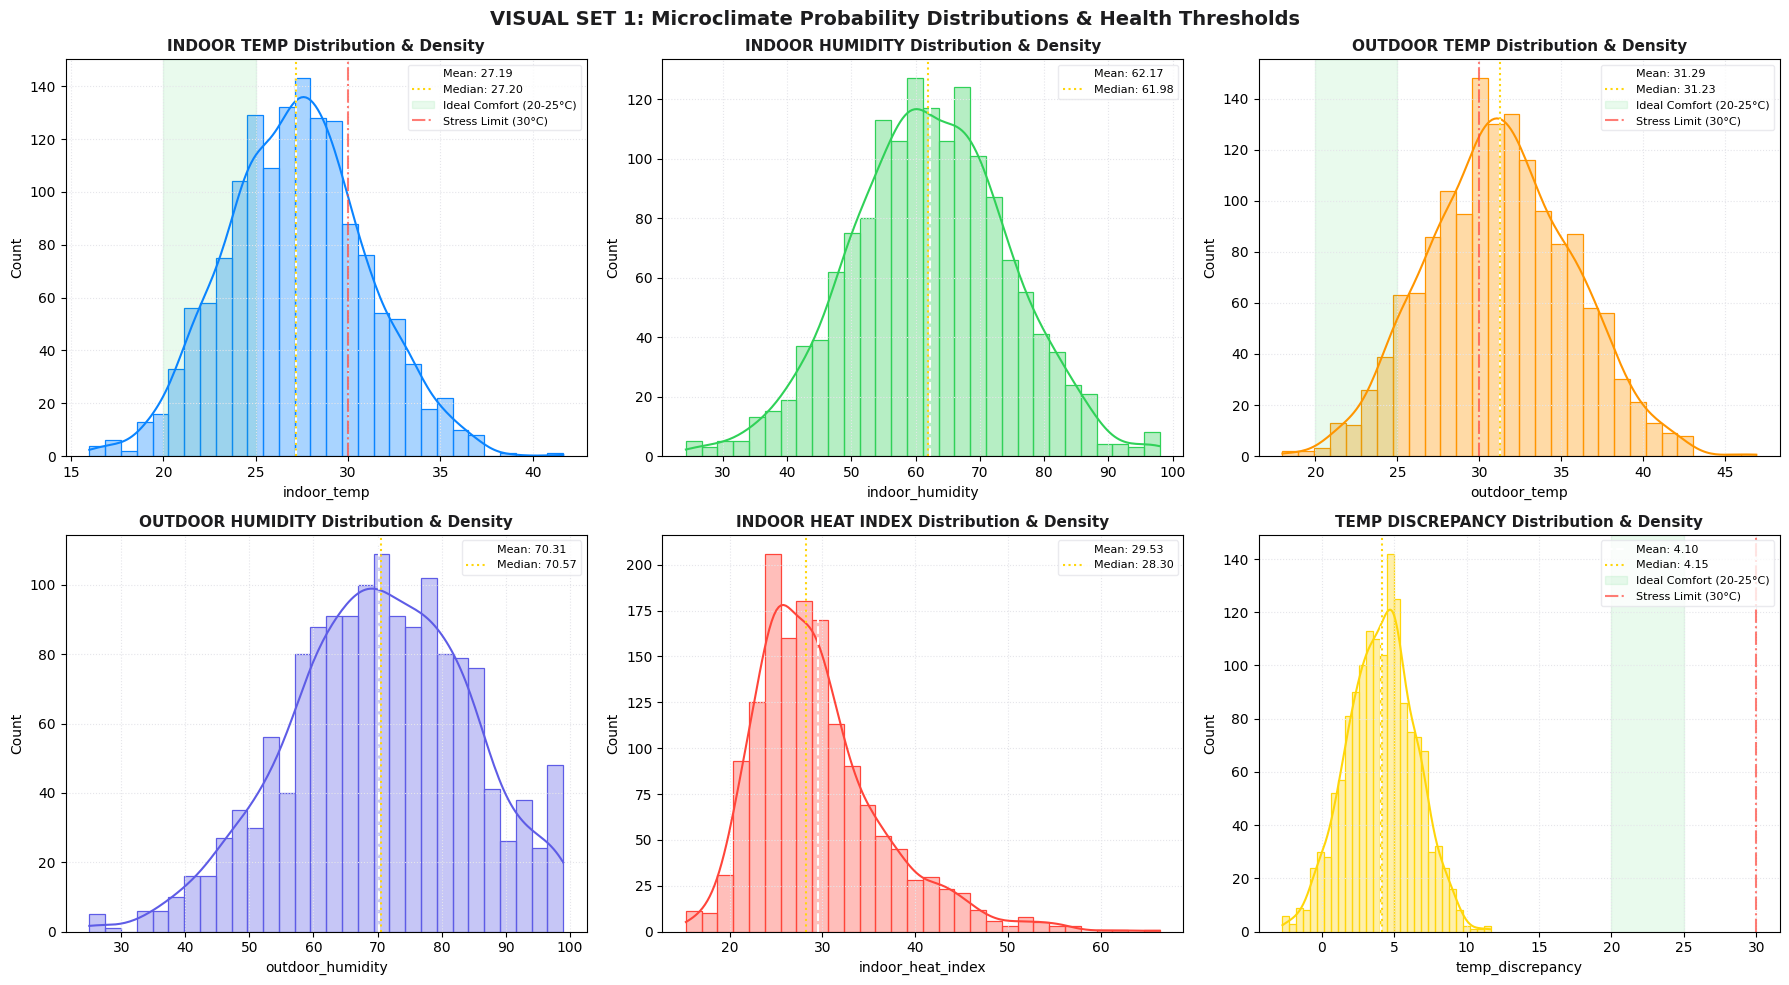

In [52]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10), facecolor=BG_COLOR)
axes = axes.flatten()

metrics = ['indoor_temp', 'indoor_humidity', 'outdoor_temp', 'outdoor_humidity', 'indoor_heat_index', 'temp_discrepancy']
palette = ['#0a84ff', '#30d158', '#ff9500', '#5e5ce6', '#ff453a', '#ffd60a']

for ax, col, color in zip(axes, metrics, palette):
    ax.set_facecolor(PANEL_BG)
    sns.histplot(df[col], kde=True, ax=ax, color=color, bins=30, alpha=0.35, edgecolor=color)
    mean_val = df[col].mean()
    median_val = df[col].median()
    ax.axvline(mean_val, color='#ffffff', linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.2f}')
    ax.axvline(median_val, color='#ffd60a', linestyle=':', linewidth=1.5, label=f'Median: {median_val:.2f}')

    # Clinical benchmarks for temperature
    if 'temp' in col:
        ax.axvspan(20, 25, color='#30d158', alpha=0.10, label='Ideal Comfort (20-25°C)')
        ax.axvline(30.0, color='#ff453a', linestyle='-.', alpha=0.7, label='Stress Limit (30°C)')

    ax.set_title(f'{col.replace("_", " ").upper()} Distribution & Density', color=TEXT_COLOR, fontsize=11, weight='bold')
    ax.grid(True, color=GRID_COLOR, linestyle=':')
    ax.legend(facecolor=BG_COLOR, edgecolor=GRID_COLOR, fontsize=8, loc='upper right')

plt.suptitle("VISUAL SET 1: Microclimate Probability Distributions & Health Thresholds", color=TEXT_COLOR, fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

INTER-METRIC CORRELATION HEATMAP (PEARSON R)

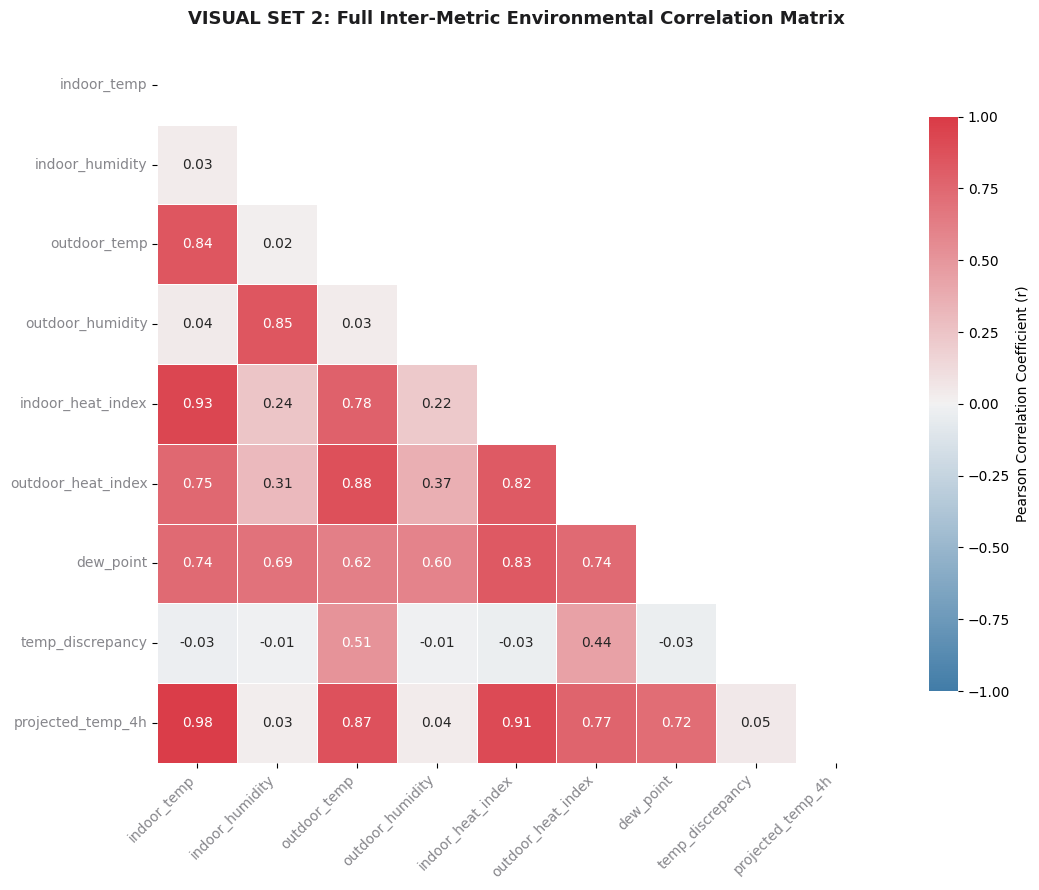

In [53]:
plt.figure(figsize=(12, 9), facecolor=BG_COLOR)
ax = plt.gca()
ax.set_facecolor(PANEL_BG)

corr_cols = ['indoor_temp', 'indoor_humidity', 'outdoor_temp', 'outdoor_humidity',
             'indoor_heat_index', 'outdoor_heat_index', 'dew_point', 'temp_discrepancy', 'projected_temp_4h']
corr_matrix = df[corr_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
cmap = sns.diverging_palette(240, 10, as_cmap=True)

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap=cmap, vmin=-1, vmax=1,
            square=True, linewidths=0.5, linecolor=BG_COLOR, ax=ax,
            cbar_kws={"shrink": 0.8, "label": "Pearson Correlation Coefficient (r)"})

plt.title("VISUAL SET 2: Full Inter-Metric Environmental Correlation Matrix", color=TEXT_COLOR, fontsize=13, weight='bold', pad=15)
plt.xticks(rotation=45, ha='right', color='#86868b')
plt.yticks(color='#86868b')
plt.tight_layout()
plt.show()

MICROCLIMATIC SCATTER DYNAMICS & REGRESSION PROFILES

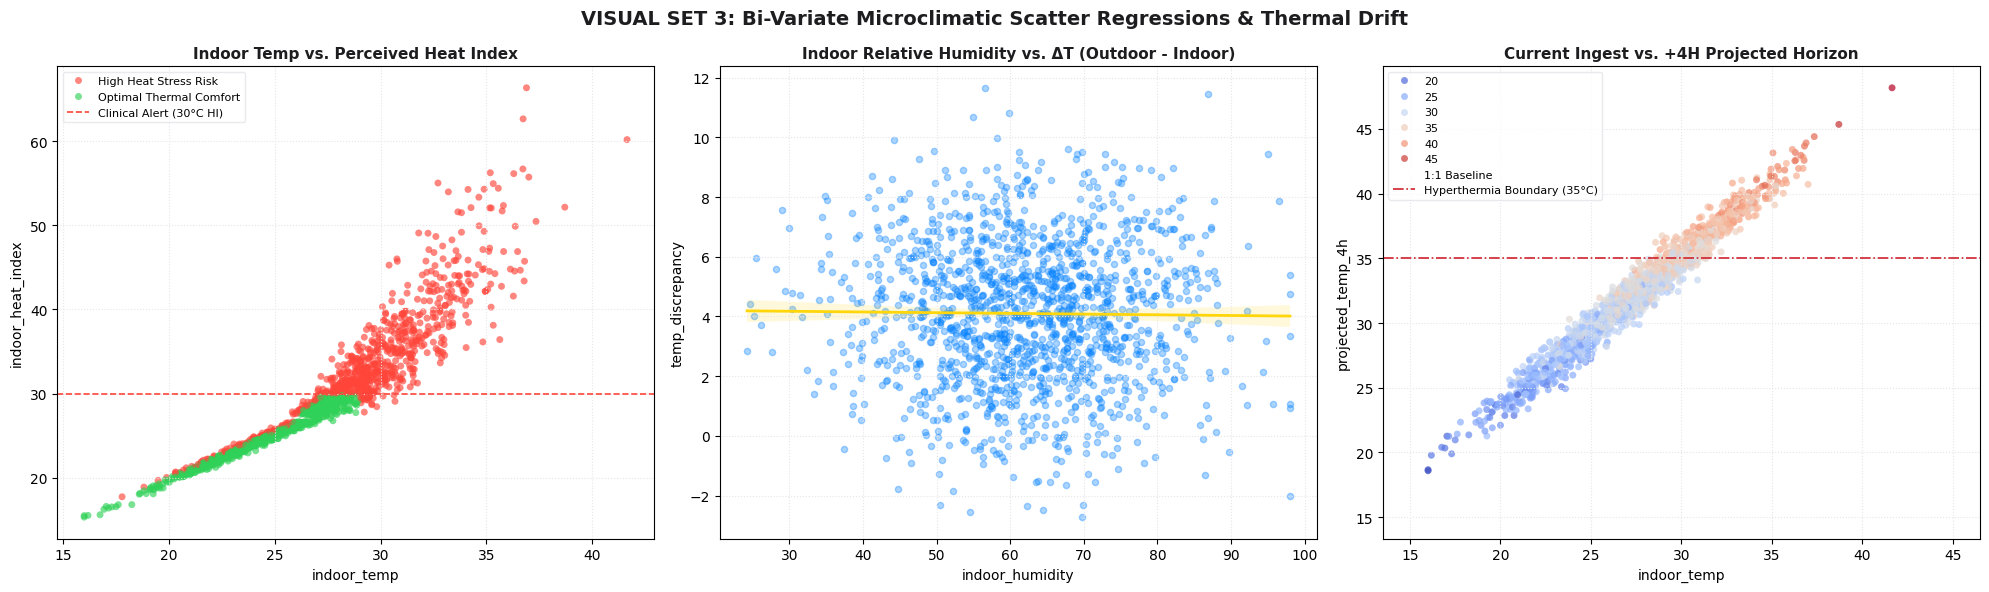

In [54]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6), facecolor=BG_COLOR)

# 1. Indoor Temp vs Heat Index categorized by Stress Risk
ax1 = axes[0]
ax1.set_facecolor(PANEL_BG)
sns.scatterplot(data=df, x='indoor_temp', y='indoor_heat_index', hue='comfort_status',
                palette={'Optimal Thermal Comfort': '#30d158', 'High Heat Stress Risk': '#ff453a'},
                alpha=0.65, ax=ax1, edgecolor='none', s=25)
ax1.axhline(30.0, color='#ff453a', linestyle='--', linewidth=1.2, label='Clinical Alert (30°C HI)')
ax1.set_title("Indoor Temp vs. Perceived Heat Index", color=TEXT_COLOR, fontsize=11, weight='bold')
ax1.grid(True, color=GRID_COLOR, linestyle=':')
ax1.legend(facecolor=BG_COLOR, edgecolor=GRID_COLOR, fontsize=8)

# 2. Indoor Humidity vs Temperature Discrepancy with OLS Trend
ax2 = axes[1]
ax2.set_facecolor(PANEL_BG)
sns.regplot(data=df, x='indoor_humidity', y='temp_discrepancy', ax=ax2,
            color='#0a84ff', scatter_kws={'alpha': 0.35, 's': 20}, line_kws={'color': '#ffd60a', 'linewidth': 2})
ax2.set_title("Indoor Relative Humidity vs. ΔT (Outdoor - Indoor)", color=TEXT_COLOR, fontsize=11, weight='bold')
ax2.grid(True, color=GRID_COLOR, linestyle=':')

# 3. Microclimate Forecast: Current Indoor Temp vs 4-Hour Projection
ax3 = axes[2]
ax3.set_facecolor(PANEL_BG)
sns.scatterplot(data=df, x='indoor_temp', y='projected_temp_4h', hue='outdoor_temp',
                palette='coolwarm', alpha=0.7, ax=ax3, edgecolor='none', s=25)
ax3.plot([15, 45], [15, 45], color='#ffffff', linestyle=':', linewidth=1.5, label='1:1 Baseline')
ax3.axhline(35.0, color='#cf222e', linestyle='-.', linewidth=1.2, label='Hyperthermia Boundary (35°C)')
ax3.set_title("Current Ingest vs. +4H Projected Horizon", color=TEXT_COLOR, fontsize=11, weight='bold')
ax3.grid(True, color=GRID_COLOR, linestyle=':')
ax3.legend(facecolor=BG_COLOR, edgecolor=GRID_COLOR, fontsize=8)

plt.suptitle("VISUAL SET 3: Bi-Variate Microclimatic Scatter Regressions & Thermal Drift", color=TEXT_COLOR, fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

VIOLIN & BOX DISTRIBUTIONS ACROSS COMFORT STATES

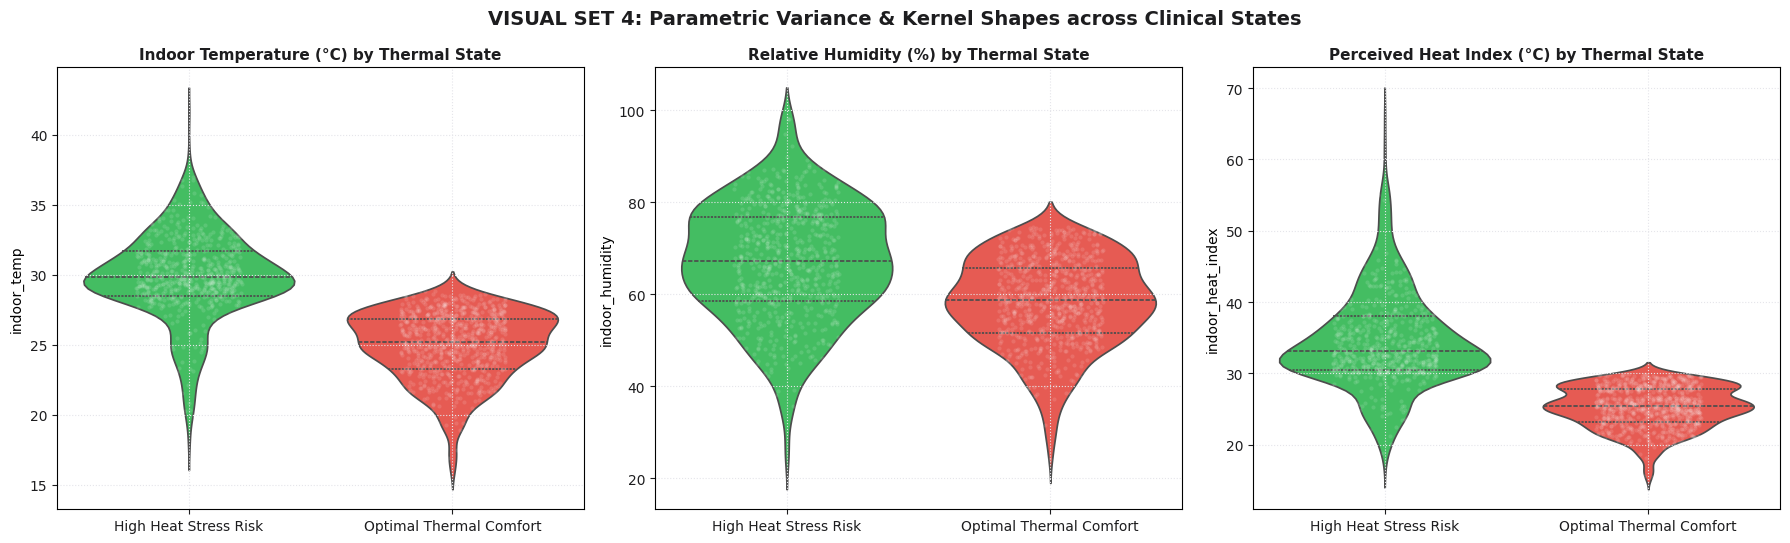

In [55]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), facecolor=BG_COLOR)

box_targets = [('indoor_temp', "Indoor Temperature (°C)"),
               ('indoor_humidity', "Relative Humidity (%)"),
               ('indoor_heat_index', "Perceived Heat Index (°C)")]

for ax, (target, label) in zip(axes, box_targets):
    ax.set_facecolor(PANEL_BG)
    sns.violinplot(data=df, x='comfort_status', y=target, ax=ax, palette=['#30d158', '#ff453a'], inner='quartile')
    sns.stripplot(data=df, x='comfort_status', y=target, ax=ax, color='#ffffff', alpha=0.12, jitter=0.2, size=3)
    ax.set_title(f'{label} by Thermal State', color=TEXT_COLOR, fontsize=11, weight='bold')
    ax.set_xlabel('')
    ax.grid(True, color=GRID_COLOR, linestyle=':')
    ax.tick_params(colors=TEXT_COLOR)

plt.suptitle("VISUAL SET 4: Parametric Variance & Kernel Shapes across Clinical States", color=TEXT_COLOR, fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

FLASK APP MIRROR DASHBOARD (DISCREPANCY & 4H PROFILE)

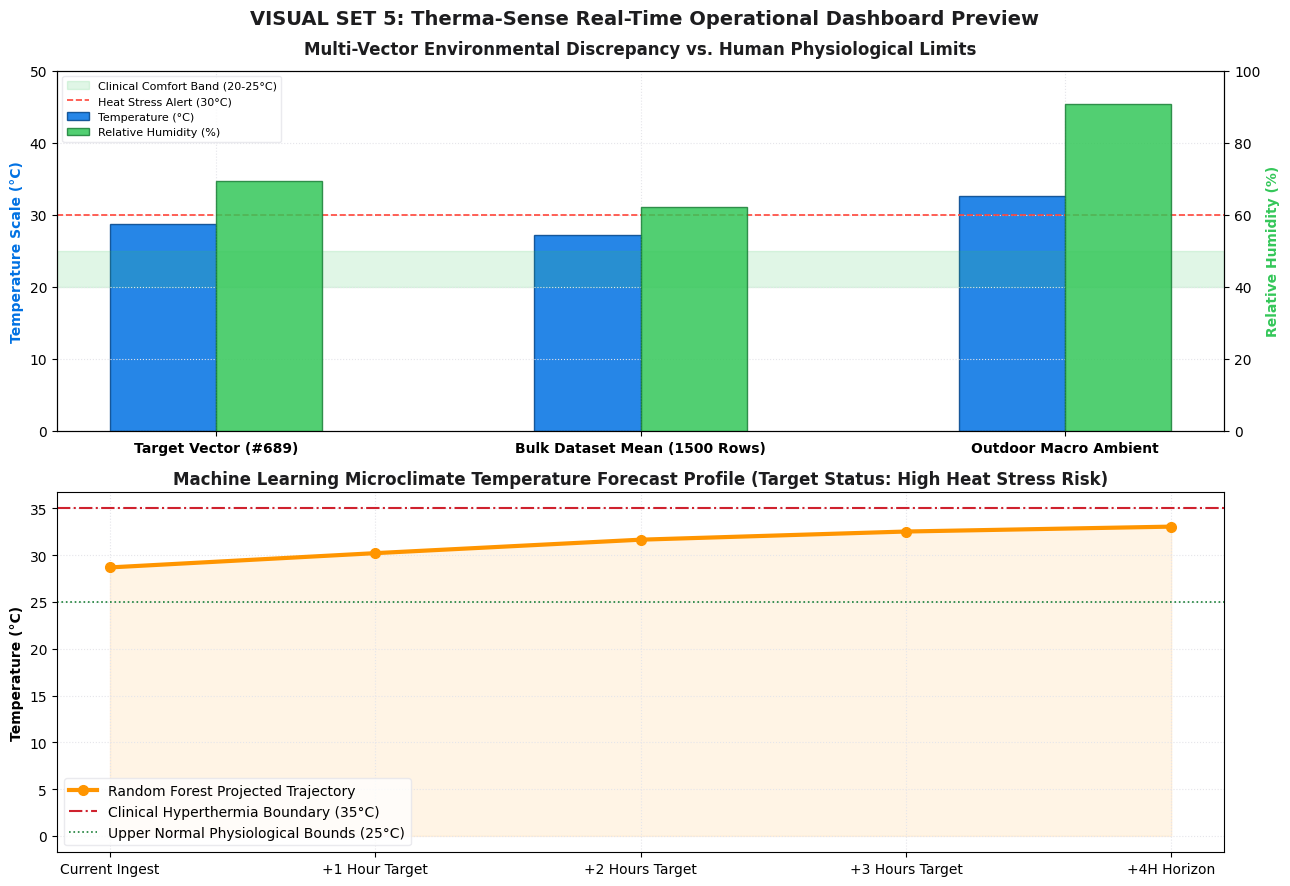

In [56]:
# Replicates and evaluates the exact visual analytics pipeline from app.py
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 9), facecolor=BG_COLOR)

sample_idx = int(np.random.randint(0, len(df)))
sample_row = df.iloc[sample_idx]

# Subplot 1: Vector Environmental Discrepancy
indices = np.arange(3)
width = 0.25
temp_vals = [sample_row['indoor_temp'], df['indoor_temp'].mean(), sample_row['outdoor_temp']]
hum_vals = [sample_row['indoor_humidity'], df['indoor_humidity'].mean(), sample_row['outdoor_humidity']]

ax1.set_facecolor(PANEL_BG)
bar1 = ax1.bar(indices - width/2, temp_vals, width, label='Temperature (°C)', color='#0071e3', alpha=0.85, edgecolor='#00458b')
ax1.set_ylabel('Temperature Scale (°C)', color='#0071e3', fontweight='bold')
ax1.set_ylim(0, 50)
ax1.axhspan(20, 25, color='#34c759', alpha=0.15, label='Clinical Comfort Band (20-25°C)')
ax1.axhline(30.0, color='#ff453a', linestyle='--', linewidth=1.2, label='Heat Stress Alert (30°C)')

ax1_twin = ax1.twinx()
bar2 = ax1_twin.bar(indices + width/2, hum_vals, width, label='Relative Humidity (%)', color='#34c759', alpha=0.85, edgecolor='#1a7f37')
ax1_twin.set_ylabel('Relative Humidity (%)', color='#34c759', fontweight='bold')
ax1_twin.set_ylim(0, 100)

ax1.set_xticks(indices)
ax1.set_xticklabels([f'Target Vector (#{sample_idx})', f'Bulk Dataset Mean ({len(df)} Rows)', 'Outdoor Macro Ambient'], fontweight='bold')
ax1.set_title('Multi-Vector Environmental Discrepancy vs. Human Physiological Limits', fontsize=12, fontweight='bold', pad=12, color=TEXT_COLOR)

# Unified Legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1_twin.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', facecolor=BG_COLOR, edgecolor=GRID_COLOR, fontsize=8)
ax1.grid(True, color=GRID_COLOR, linestyle=':')

# Subplot 2: 4-Hour Proportional Forecast Curve
ax2.set_facecolor(PANEL_BG)
t_in = sample_row['indoor_temp']
t_trend = sample_row['projected_temp_4h']
time_horizons = ['Current Ingest', '+1 Hour Target', '+2 Hours Target', '+3 Hours Target', '+4H Horizon']
temp_curve = [t_in, t_in + (t_trend - t_in)*0.35, t_in + (t_trend - t_in)*0.68, t_in + (t_trend - t_in)*0.88, t_trend]

ax2.plot(time_horizons, temp_curve, marker='o', markersize=7, linestyle='-', color='#ff9500', linewidth=3, label='Random Forest Projected Trajectory')
ax2.fill_between(time_horizons, temp_curve, color='#ff9500', alpha=0.10)
ax2.axhline(35.0, color='#cf222e', linestyle='-.', linewidth=1.5, label='Clinical Hyperthermia Boundary (35°C)')
ax2.axhline(25.0, color='#1a7f37', linestyle=':', linewidth=1.2, label='Upper Normal Physiological Bounds (25°C)')
ax2.set_ylabel('Temperature (°C)', fontweight='bold')
ax2.set_title(f'Machine Learning Microclimate Temperature Forecast Profile (Target Status: {sample_row["comfort_status"]})', fontsize=12, fontweight='bold', color=TEXT_COLOR)
ax2.legend(loc='lower left', facecolor=BG_COLOR, edgecolor=GRID_COLOR)
ax2.grid(True, color=GRID_COLOR, linestyle=':')

plt.suptitle("VISUAL SET 5: Therma-Sense Real-Time Operational Dashboard Preview", color=TEXT_COLOR, fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

EDGE ML RETRAINING & ARTIFACT GENERATION (ANN + RANDOM FOREST)

In [48]:
print("\n" + "="*70)
print(">>> EXECUTING MACHINE LEARNING ENGINE & MODEL VALIDATION")
print("="*70)

feature_cols = ['indoor_temp', 'indoor_humidity', 'outdoor_temp', 'outdoor_humidity']
X = df[feature_cols].values
y_class = df['heat_stress_risk'].values
y_reg = df['projected_temp_4h'].values

X_train, X_test, y_c_train, y_c_test, y_r_train, y_r_test = train_test_split(
    X, y_class, y_reg, test_size=0.20, random_state=42, stratify=y_class
)

# 1. Classification Model: Multi-Layer Perceptron (MLP)
ann_model = MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=600, random_state=42)
ann_model.fit(X_train, y_c_train)
y_c_pred = ann_model.predict(X_test)

print("\n--- [1] ARTIFICIAL NEURAL NETWORK CLASSIFICATION REPORT ---")
print(classification_report(y_c_test, y_c_pred, target_names=['Optimal Comfort (0)', 'Heat Stress Risk (1)']))

# 2. Regression Model: Random Forest Regressor
regressor_model = RandomForestRegressor(n_estimators=60, random_state=42)
regressor_model.fit(X_train, y_r_train)
y_r_pred = regressor_model.predict(X_test)

r2 = r2_score(y_r_test, y_r_pred)
rmse = np.sqrt(mean_squared_error(y_r_test, y_r_pred))
mae = mean_absolute_error(y_r_test, y_r_pred)

print("--- [2] RANDOM FOREST REGRESSOR METRICS ---")
print(f"R² Score              : {r2:.4f}")
print(f"Root Mean Squared Err : {rmse:.4f} °C")
print(f"Mean Absolute Error   : {mae:.4f} °C")


>>> EXECUTING MACHINE LEARNING ENGINE & MODEL VALIDATION

--- [1] ARTIFICIAL NEURAL NETWORK CLASSIFICATION REPORT ---
                      precision    recall  f1-score   support

 Optimal Comfort (0)       0.92      0.94      0.93       161
Heat Stress Risk (1)       0.93      0.90      0.92       139

            accuracy                           0.92       300
           macro avg       0.92      0.92      0.92       300
        weighted avg       0.92      0.92      0.92       300

--- [2] RANDOM FOREST REGRESSOR METRICS ---
R² Score              : 0.9625
Root Mean Squared Err : 0.8271 °C
Mean Absolute Error   : 0.6694 °C


CONFUSION MATRIX & PREDICTION ERROR RESIDUALS

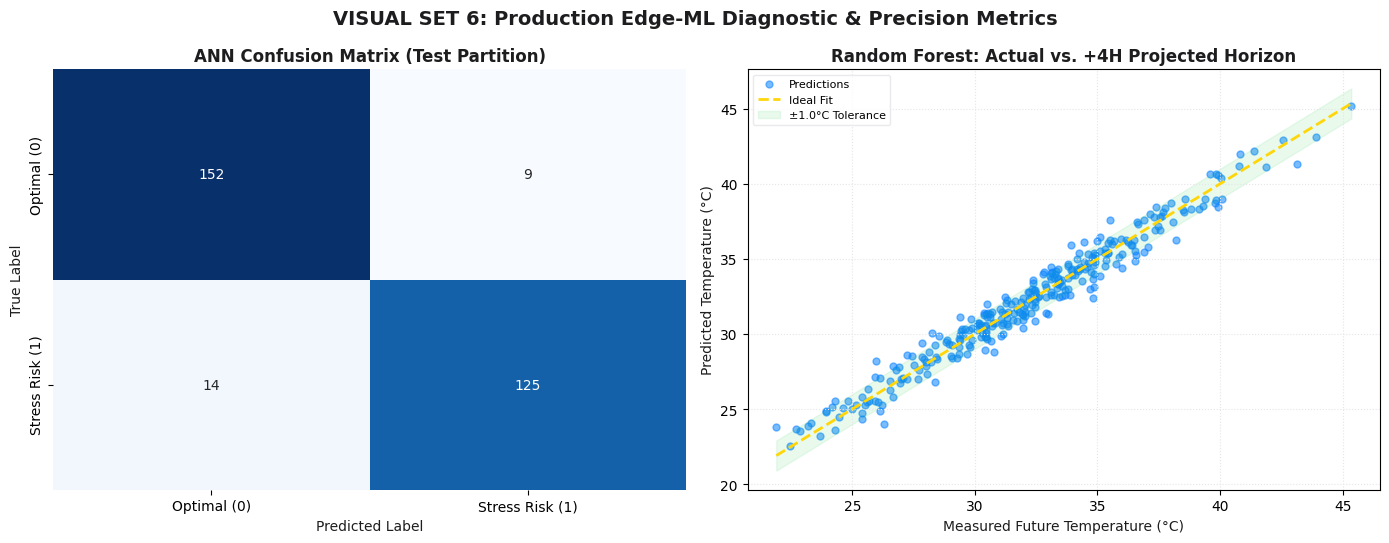

In [57]:
fig, (ax_cm, ax_res) = plt.subplots(1, 2, figsize=(14, 5.5), facecolor=BG_COLOR)

# Confusion Matrix Heatmap
ax_cm.set_facecolor(PANEL_BG)
cm = confusion_matrix(y_c_test, y_c_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap='Blues', cbar=False, ax=ax_cm,
            xticklabels=['Optimal (0)', 'Stress Risk (1)'], yticklabels=['Optimal (0)', 'Stress Risk (1)'])
ax_cm.set_title("ANN Confusion Matrix (Test Partition)", color=TEXT_COLOR, weight='bold')
ax_cm.set_ylabel("True Label", color=TEXT_COLOR)
ax_cm.set_xlabel("Predicted Label", color=TEXT_COLOR)

# Regression Actual vs Predicted with ±1.5°C Error Tolerance Band
ax_res.set_facecolor(PANEL_BG)
ax_res.scatter(y_r_test, y_r_pred, color='#0a84ff', alpha=0.55, s=25, label='Predictions')
min_val = min(y_r_test.min(), y_r_pred.min())
max_val = max(y_r_test.max(), y_r_pred.max())
ax_res.plot([min_val, max_val], [min_val, max_val], color='#ffd60a', linestyle='--', linewidth=2, label='Ideal Fit')
ax_res.fill_between([min_val, max_val], [min_val - 1.0, max_val - 1.0], [min_val + 1.0, max_val + 1.0],
                    color='#30d158', alpha=0.10, label='±1.0°C Tolerance')
ax_res.set_title("Random Forest: Actual vs. +4H Projected Horizon", color=TEXT_COLOR, weight='bold')
ax_res.set_xlabel("Measured Future Temperature (°C)", color=TEXT_COLOR)
ax_res.set_ylabel("Predicted Temperature (°C)", color=TEXT_COLOR)
ax_res.legend(facecolor=BG_COLOR, edgecolor=GRID_COLOR, fontsize=8)
ax_res.grid(True, color=GRID_COLOR, linestyle=':')

plt.suptitle("VISUAL SET 6: Production Edge-ML Diagnostic & Precision Metrics", color=TEXT_COLOR, fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

PERSISTENCE FOR FLASK DEPLOYMENT (app.py READY)

In [50]:
os.makedirs('models', exist_ok=True)
with open('models/ann_model.pkl', 'wb') as f:
    pickle.dump(ann_model, f)
with open('models/regressor.pkl', 'wb') as f:
    pickle.dump(regressor_model, f)

print("\n[✓] Models successfully serialized to 'models/ann_model.pkl' and 'models/regressor.pkl'.")
print("[✓] 'data.csv' updated with enriched microclimate feature vectors.")


[✓] Models successfully serialized to 'models/ann_model.pkl' and 'models/regressor.pkl'.
[✓] 'data.csv' updated with enriched microclimate feature vectors.
